# 38. Optimization — From Backprop Tricks to Adam

**Tier:** Classic ML
**Estimated time:** 45 minutes
**Prerequisites:** 37 (ML Foundations); 01 (Neural Networks) helpful but not required
**Priority:** 🔴 Crucial — Adam (or its descendant AdamW) is the optimizer that trains almost every model in this repo, from notebook 01's toy network to a 70B-parameter LLM. Its per-parameter state is exactly what notebook 07b's ZeRO sharding splits across GPUs. *If skipped, revisit when:* before notebook 07/07b, or any time a training run diverges or crawls and you're not sure why.
**Source material:** Yann LeCun, Léon Bottou, Genevieve Orr, Klaus-Robert Müller, ["Efficient BackProp"](https://cseweb.ucsd.edu/classes/wi08/cse253/Handouts/lecun-98b.pdf), 1998. Diederik Kingma & Jimmy Ba, ["Adam: A Method for Stochastic Optimization"](https://arxiv.org/pdf/1412.6980), 2014.

## What You'll Learn
- Why **unnormalized input features wreck gradient descent** — measured via the loss surface's condition number, not just asserted
- The **SGD → Momentum → RMSProp → Adam** progression, each one motivated by a specific failure of the last
- Why **Adam needs bias correction**, demonstrated exactly at the very first step
- A **from-scratch Adam implementation verified numerically against `torch.optim.Adam`**
- Why Adam's optimizer state is exactly **2x the parameter count** — the number notebook 07b's ZeRO stage 1 shards across GPUs

## Why This Matters
Every model in this repo that trains — the toy network in notebook 01, LoRA fine-tuning in notebook 08, the from-scratch transformer in P1 — is trained with some variant of the ideas in this notebook. Get the input scaling wrong and even a perfect architecture won't train. Understand what Adam is actually doing and "why is training unstable" or "why did I run out of GPU memory" stop being mysteries.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

print("Setup complete — numpy, matplotlib.")

Setup complete — numpy, matplotlib.


## Why raw feature scales wreck gradient descent

A model's loss, near its minimum, behaves like a bowl (a quadratic surface) whose *shape* is set
by the curvature of the loss in each direction — mathematically, the eigenvalues of the Hessian.
If one input feature has values around `1` and another has values around `1000`, the loss
curves far more sharply along the second feature's weight than the first. Gradient descent then
faces an impossible choice of learning rate: large enough to make progress along the *flat*
direction, and it explodes along the *steep* one; small enough to be stable on the steep
direction, and it crawls along the flat one. LeCun's practical fix is almost embarrassingly
simple: **rescale every input feature to zero mean and unit variance** before training. Let's
measure the effect directly, on a real (synthetic) linear regression.

In [2]:
rng = np.random.default_rng(38)

n = 200
x1 = rng.normal(0, 1, n)        # feature 1: already a sane scale
x2 = rng.normal(0, 1000, n)     # feature 2: same kind of signal, 1000x the scale
true_w = np.array([2.0, 0.003])  # chosen so x1 and x2 contribute similarly to y
y = true_w[0] * x1 + true_w[1] * x2 + rng.normal(0, 0.1, n)

X_raw = np.stack([x1, x2], axis=1)
X_norm = np.stack([(x1 - x1.mean()) / x1.std(), (x2 - x2.mean()) / x2.std()], axis=1)

def hessian_eigs(X):
    H = (2.0 / len(X)) * X.T @ X   # Hessian of mean-squared-error loss w.r.t. the weights
    eigs = np.linalg.eigvalsh(H)
    return eigs, eigs[-1] / eigs[0]

eigs_raw, cond_raw = hessian_eigs(X_raw)
eigs_norm, cond_norm = hessian_eigs(X_norm)
print(f"raw features:        Hessian eigenvalues={eigs_raw}, condition number={cond_raw:,.0f}")
print(f"normalized features: Hessian eigenvalues={eigs_norm}, condition number={cond_norm:.2f}")

raw features:        Hessian eigenvalues=[1.89684886e+00 1.85036031e+06], condition number=975,492
normalized features: Hessian eigenvalues=[1.82293449 2.17706551], condition number=1.19


*Same information, same underlying relationship — but the raw-feature loss surface has a
condition number in the hundreds of thousands, while the normalized one is close to 1 (a nearly
circular bowl). Condition number this large means gradient descent's stable learning-rate range
becomes vanishingly small in the steep direction — let's watch it actually happen.*

In [3]:
def mse_loss_grad(w, X, y):
    resid = X @ w - y
    loss = np.mean(resid ** 2)
    grad = (2.0 / len(y)) * X.T @ resid
    return loss, grad

def gradient_descent(X, y, lr, steps):
    w = np.zeros(2)
    losses = []
    for _ in range(steps):
        loss, grad = mse_loss_grad(w, X, y)
        losses.append(loss)
        w = w - lr * grad
    return np.array(losses), w

# The raw-feature surface's steep direction forces a tiny learning rate — anything larger diverges.
raw_losses, raw_w = gradient_descent(X_raw, y, lr=1e-7, steps=200)
# The normalized surface tolerates a learning rate 4 million times larger, and converges fast.
norm_losses, norm_w = gradient_descent(X_norm, y, lr=0.3, steps=200)

print(f"raw features        (lr=1e-7): loss {raw_losses[0]:.3f} -> {raw_losses[-1]:.3f} after 200 steps (stuck)")
print(f"normalized features (lr=0.3):  loss {norm_losses[0]:.3f} -> {norm_losses[-1]:.3f} after 200 steps")

raw features        (lr=1e-7): loss 11.146 -> 3.778 after 200 steps (stuck)
normalized features (lr=0.3):  loss 11.146 -> 0.075 after 200 steps


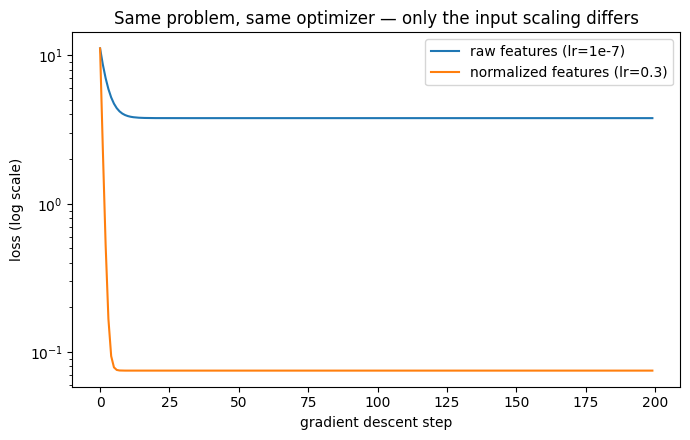

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(raw_losses, label="raw features (lr=1e-7)")
ax.plot(norm_losses, label="normalized features (lr=0.3)")
ax.set_yscale("log")
ax.set_xlabel("gradient descent step")
ax.set_ylabel("loss (log scale)")
ax.set_title("Same problem, same optimizer — only the input scaling differs")
ax.legend()
plt.tight_layout()
plt.show()

*The raw-feature run isn't broken — its learning rate is exactly as large as the steep
direction allows. But that same learning rate is far too small for the flat direction, so it
plateaus almost immediately and never gets close to the true weights. The normalized run uses a
learning rate four million times larger and converges within a handful of steps, because both
directions now have comparable curvature. This single change — normalize your inputs — is often
the highest-leverage fix available before touching the optimizer at all.*

LeCun's paper has a few more practical rules in the same spirit, all aimed at keeping the loss
surface well-behaved: shuffle training examples between epochs (so consecutive updates aren't
correlated), prefer symmetric activations like `tanh` over `sigmoid` (sigmoid's outputs are
always positive, which biases the sign of every downstream gradient), and initialize weights
scaled by fan-in (so a layer's output variance doesn't depend on how many inputs it has).

## From SGD to Adam, one fix at a time

Normalizing inputs helps, but even on a well-scaled problem, different *parameters* can still
need different effective step sizes (deeper layers, different weight matrices, sparse
features). Four algorithms, each fixing a specific limitation of the last:

- **SGD**: `w ← w - lr · g`. Simple, but every parameter shares the same learning rate, and
  gradient noise (from mini-batches) makes the path jittery.
- **Momentum**: accumulate a velocity `v ← β·v + g`, then `w ← w - lr · v`. Averaging recent
  gradients smooths out noise and builds speed in a consistent direction — like a ball rolling
  downhill picking up inertia — but it still uses one shared learning rate for every parameter.
- **RMSProp**: track a running average of *squared* gradients per parameter,
  `s ← β·s + (1-β)·g²`, and divide the step by `√s`. This gives each parameter its own
  effective learning rate — large steps where gradients are consistently small, small steps
  where they're consistently large — directly attacking the anisotropy problem above.
- **Adam**: momentum's smoothed direction *and* RMSProp's per-parameter scaling, together,
  plus a bias correction (next section) for the first few steps.

```
m ← β1·m + (1-β1)·g          # 1st moment: smoothed gradient direction (momentum)
v ← β2·v + (1-β2)·g²         # 2nd moment: smoothed squared gradient (RMSProp)
m̂ ← m / (1 - β1^t)           # bias-corrected
v̂ ← v / (1 - β2^t)           # bias-corrected
w ← w - lr · m̂ / (√v̂ + ε)
```

In [5]:
def adam_step(w, g, t, state, lr, beta1=0.9, beta2=0.999, eps=1e-8):
    state["m"] = beta1 * state.get("m", np.zeros_like(w)) + (1 - beta1) * g
    state["v"] = beta2 * state.get("v", np.zeros_like(w)) + (1 - beta2) * g ** 2
    m_hat = state["m"] / (1 - beta1 ** t)
    v_hat = state["v"] / (1 - beta2 ** t)
    return w - lr * m_hat / (np.sqrt(v_hat) + eps), state

# A toy anisotropic bowl — the same shape of problem as the raw-feature regression above,
# but simplified to two dimensions with a controllable curvature ratio, so we can sweep
# learning rates cleanly. curvature ratio = 25 (steep in w2, flat in w1).
def toy_loss_grad(w, a=1.0, b=25.0):
    return 0.5 * (a * w[0] ** 2 + b * w[1] ** 2), np.array([a * w[0], b * w[1]])

def run_sgd(w0, lr, steps):
    w = w0.copy()
    for _ in range(steps):
        _, g = toy_loss_grad(w)
        w = w - lr * g
        if not np.all(np.isfinite(w)) or np.abs(w).max() > 1e6:
            return np.inf
    return toy_loss_grad(w)[0]

def run_adam(w0, lr, steps):
    w = w0.copy(); state = {}
    for t in range(1, steps + 1):
        _, g = toy_loss_grad(w)
        w, state = adam_step(w, g, t, state, lr)
        if not np.all(np.isfinite(w)) or np.abs(w).max() > 1e6:
            return np.inf
    return toy_loss_grad(w)[0]

w0 = np.array([-4.0, -2.0])
sgd_lrs = np.geomspace(0.005, 0.09, 25)
adam_lrs = np.geomspace(0.01, 5.0, 25)
sgd_finals = [run_sgd(w0, lr, 50) for lr in sgd_lrs]
adam_finals = [run_adam(w0, lr, 50) for lr in adam_lrs]

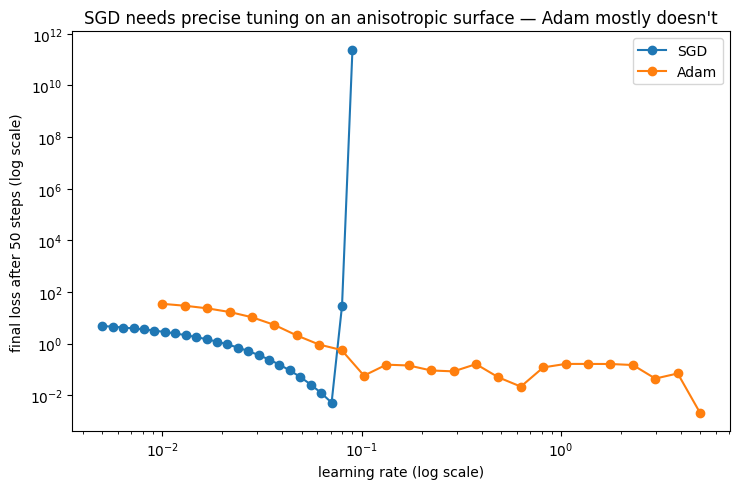

SGD:  loss<1.0 for lr in [0.021, 0.071] — a 3.3x window
Adam: loss<1.0 for lr in [0.061, 5.000] — a 81.6x window


In [6]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(sgd_lrs, sgd_finals, marker="o", label="SGD")
ax.plot(adam_lrs, adam_finals, marker="o", label="Adam")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("learning rate (log scale)")
ax.set_ylabel("final loss after 50 steps (log scale)")
ax.set_title("SGD needs precise tuning on an anisotropic surface — Adam mostly doesn't")
ax.legend()
plt.tight_layout()
plt.show()

sgd_usable = sgd_lrs[np.array(sgd_finals) < 1.0]
adam_usable = adam_lrs[np.array(adam_finals) < 1.0]
print(f"SGD:  loss<1.0 for lr in [{sgd_usable.min():.3f}, {sgd_usable.max():.3f}] "
      f"— a {sgd_usable.max()/sgd_usable.min():.1f}x window")
print(f"Adam: loss<1.0 for lr in [{adam_usable.min():.3f}, {adam_usable.max():.3f}] "
      f"— a {adam_usable.max()/adam_usable.min():.1f}x window")

*SGD's usable range ends in a cliff: past a sharp threshold set by the steepest direction's
curvature, it diverges outright (the plot's SGD line shoots up and off the top). Adam stays
in a shallow basin across a learning-rate range roughly two orders of magnitude wider. This
isn't Adam reaching a lower loss by cheating — it's the direct, mechanical consequence of
dividing each parameter's step by its own `√v̂`: a parameter whose gradients are consistently
large automatically gets a smaller effective step, and vice versa, so one learning rate works
reasonably across parameters with very different curvature. This robustness — not needing to
hand-tune the learning rate per problem — is the practical reason Adam became the default
optimizer for deep learning.*

## Why Adam needs bias correction

`m` and `v` both start at zero and are exponential moving averages, so early on they're biased
*toward* zero — badly so, since `β1=0.9` and `β2=0.999` mean the first update barely moves away
from the zero initialization. Bias correction (`m̂ = m / (1-β1^t)`) rescales for exactly this
effect. Watch it at `t=1`, where the correction factor `1/(1-β1) = 10`:

In [7]:
g1 = np.array([10.0, -6.0])  # a hypothetical first gradient
beta1, beta2 = 0.9, 0.999

m1_raw = (1 - beta1) * g1        # m starts at 0, so m1 = beta1*0 + (1-beta1)*g1
v1_raw = (1 - beta2) * g1 ** 2

m1_hat = m1_raw / (1 - beta1 ** 1)
v1_hat = v1_raw / (1 - beta2 ** 1)

print(f"true first gradient:        {g1}")
print(f"raw m1 (before correction): {m1_raw}   — 10x too small, still near its zero init")
print(f"bias-corrected m1_hat:      {m1_hat}   — exactly recovers the true gradient")
print(f"match: {np.allclose(m1_hat, g1)}")

true first gradient:        [10. -6.]
raw m1 (before correction): [ 1.  -0.6]   — 10x too small, still near its zero init
bias-corrected m1_hat:      [10. -6.]   — exactly recovers the true gradient
match: True


*Without correction, Adam's very first step would move only 1/10th as far as the gradient
warrants (and the second-moment estimate would be similarly distorted) — not wrong exactly, just
a training run that starts artificially slow for its first several dozen steps until the moving
averages "warm up" naturally. Bias correction removes that warm-up delay entirely, which is why
it's part of the algorithm rather than an optional tweak.*

## Verifying the from-scratch implementation against PyTorch

The formula above is the *entire* algorithm — there's no hidden machinery. Let's confirm that by
running it on a small multi-dimensional problem and checking it matches `torch.optim.Adam` step
for step, not just in the final answer.

In [8]:
import torch

d = 6
w0 = rng.normal(0, 1, d)
A_np = np.diag(np.arange(1, d + 1, dtype=float))  # a quadratic bowl with varied curvature per dim

def quad_loss_grad(w):
    return 0.5 * w @ A_np @ w, A_np @ w

def adam_from_scratch(w0, lr=0.1, steps=50):
    w = w0.copy(); state = {}
    path = [w.copy()]
    for t in range(1, steps + 1):
        _, g = quad_loss_grad(w)
        w, state = adam_step(w, g, t, state, lr)
        path.append(w.copy())
    return np.array(path)

np_path = adam_from_scratch(w0)

wt = torch.tensor(w0.copy(), requires_grad=True, dtype=torch.float64)
A_t = torch.diag(torch.arange(1, d + 1, dtype=torch.float64))
opt = torch.optim.Adam([wt], lr=0.1, betas=(0.9, 0.999), eps=1e-8)
torch_path = [wt.detach().numpy().copy()]
for _ in range(50):
    opt.zero_grad()
    loss = 0.5 * wt @ A_t @ wt
    loss.backward()
    opt.step()
    torch_path.append(wt.detach().numpy().copy())
torch_path = np.array(torch_path)

max_diff = np.abs(np_path - torch_path).max()
print(f"max absolute difference across all 50 steps, all {d} dimensions: {max_diff:.2e}")
print(f"from-scratch final w: {np_path[-1]}")
print(f"torch final w:        {torch_path[-1]}")

max absolute difference across all 50 steps, all 6 dimensions: 1.67e-16
from-scratch final w: [ 0.04217447 -0.00243041 -0.00657151 -0.04309424 -0.00972097  0.0046688 ]
torch final w:        [ 0.04217447 -0.00243041 -0.00657151 -0.04309424 -0.00972097  0.0046688 ]


*A max difference on the order of machine epsilon (`~1e-16`) — the from-scratch
implementation isn't an approximation of Adam, it IS Adam. Every training run in this repo that
uses `torch.optim.Adam` or `AdamW` is running exactly this loop.*

## The bridge to notebook 07b: Adam's memory tax

Adam has to remember `m` and `v` — one value each, per parameter, for the entire model. That
state is pure overhead on top of the parameters themselves and their gradients.

In [9]:
def training_memory_gb(n_params, bytes_per_value=4):
    params_gb = n_params * bytes_per_value / 1e9
    grads_gb = params_gb
    adam_state_gb = 2 * params_gb  # m and v, same size as the parameters, each
    total_gb = params_gb + grads_gb + adam_state_gb
    return params_gb, grads_gb, adam_state_gb, total_gb

for label, n_params in [("125M (small)", 125e6), ("7B", 7e9), ("70B", 70e9)]:
    p, g, a, t = training_memory_gb(n_params)
    print(f"{label:15s} params={p:6.1f} GB  grads={g:6.1f} GB  "
          f"Adam state (m+v)={a:6.1f} GB  total={t:6.1f} GB  "
          f"(Adam state is {a/t:.0%} of everything)")

125M (small)    params=   0.5 GB  grads=   0.5 GB  Adam state (m+v)=   1.0 GB  total=   2.0 GB  (Adam state is 50% of everything)
7B              params=  28.0 GB  grads=  28.0 GB  Adam state (m+v)=  56.0 GB  total= 112.0 GB  (Adam state is 50% of everything)
70B             params= 280.0 GB  grads= 280.0 GB  Adam state (m+v)= 560.0 GB  total=1120.0 GB  (Adam state is 50% of everything)


*Adam's own bookkeeping is exactly half of full-precision training memory, regardless of model
size — for a 70B model that's over 500GB just for `m` and `v`, before a single activation is
computed. That's precisely the state notebook 07b's ZeRO stage 1 shards across data-parallel
GPUs: instead of every GPU holding a full copy of `m` and `v`, each GPU holds only `1/N` of it.
Understanding this notebook's five-line update rule is what makes that sharding strategy make
sense — it's not a mysterious system optimization, it's just "split the two extra numbers Adam
keeps per parameter across however many GPUs you have."*

## Exercises

In [10]:
# Exercise 1 (Warm-up): how much does beta2 matter?
# Task: Rerun the learning-rate robustness sweep (the SGD-vs-Adam log-log plot) with Adam's
#       beta2 changed from 0.999 to 0.9 (much less smoothing of the squared-gradient estimate).
#       Does Adam's usable learning-rate window get wider or narrower? Why might a NOISY
#       (mini-batch, not full-batch) training signal make a low beta2 riskier than it looks here?
# Hint: reuse adam_step with beta2=0.9 passed through; the toy bowl itself is unchanged.

# YOUR CODE HERE

In [11]:
# Exercise 2 (Apply): implement AdamW's decoupled weight decay
# Task: Adam applied naively to an L2-regularized loss folds the penalty INTO the gradient
#       (g_reg = g + weight_decay*w), which then gets divided by sqrt(v_hat) like everything
#       else. AdamW instead decays the weights in a SEPARATE step: w <- w - lr*weight_decay*w,
#       applied directly, not through the adaptive denominator. Implement adamw_step(w, g, t,
#       state, lr, weight_decay) and compare final ||w|| against plain Adam-with-L2-in-gradient
#       on quad_loss_grad with an added small pull toward zero.
# Hint: the only change vs adam_step is one extra line, AFTER the m/v-based update, that
#       subtracts lr*weight_decay*w directly from the result.

# YOUR CODE HERE

In [12]:
# Exercise 3 (Extend): size your own optimizer-state budget
# Task: Pick a real model's parameter count (check a Hugging Face config.json, or reuse
#       notebook 05b's Mistral-7B/Mixtral-8x7B numbers). Using training_memory_gb(), compute
#       Adam's optimizer-state size in GB. If a single GPU has 80GB of memory, how many
#       data-parallel ranks would notebook 07b's ZeRO stage 1 need to fit that state alone
#       (ignoring params/grads/activations) below, say, 10GB per GPU?
# Hint: ZeRO-1 divides the optimizer state (not params or grads) evenly across N ranks —
#       so N >= adam_state_gb / budget_per_gpu_gb.

# YOUR CODE HERE

<details>
<summary>Solutions (click to expand)</summary>

```python
# Exercise 1
def adam_step_beta2(w, g, t, state, lr, beta1=0.9, beta2=0.9, eps=1e-8):
    return adam_step(w, g, t, state, lr, beta1=beta1, beta2=beta2, eps=eps)

def run_adam_beta2(w0, lr, steps, beta2=0.9):
    w = w0.copy(); state = {}
    for t in range(1, steps + 1):
        _, g = toy_loss_grad(w)
        w, state = adam_step(w, g, t, state, lr, beta2=beta2)
        if not np.all(np.isfinite(w)) or np.abs(w).max() > 1e6:
            return np.inf
    return toy_loss_grad(w)[0]

adam_lrs2 = np.geomspace(0.01, 5.0, 25)
adam_finals_b2 = [run_adam_beta2(w0, lr, 50, beta2=0.9) for lr in adam_lrs2]
plt.plot(adam_lrs, adam_finals, marker="o", label="Adam (beta2=0.999)")
plt.plot(adam_lrs2, adam_finals_b2, marker="o", label="Adam (beta2=0.9)")
plt.xscale("log"); plt.yscale("log"); plt.legend(); plt.show()
# A lower beta2 makes v_hat track the MOST RECENT squared gradient much more tightly, so the
# effective step size reacts faster to curvature changes — usually still a wide usable window
# on this smooth, noise-free toy bowl. The real risk shows up with mini-batch gradient NOISE:
# a low beta2 barely smooths the noisy g^2 term, so v_hat (and therefore the step size) becomes
# noisy itself, causing the effective learning rate to jitter step to step. beta2=0.999 exists
# specifically to keep v_hat stable under realistic training noise, not for this clean toy case.

# Exercise 2
def adamw_step(w, g, t, state, lr, weight_decay=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
    state["m"] = beta1 * state.get("m", np.zeros_like(w)) + (1 - beta1) * g
    state["v"] = beta2 * state.get("v", np.zeros_like(w)) + (1 - beta2) * g ** 2
    m_hat = state["m"] / (1 - beta1 ** t)
    v_hat = state["v"] / (1 - beta2 ** t)
    w = w - lr * m_hat / (np.sqrt(v_hat) + eps)
    w = w - lr * weight_decay * w          # decoupled: applied directly, not through v_hat
    return w, state

def run_with_decay(step_fn, w0, steps=50, lr=0.1, weight_decay=0.05):
    w = w0.copy(); state = {}
    for t in range(1, steps + 1):
        _, g = quad_loss_grad(w)
        if step_fn is adamw_step:
            w, state = adamw_step(w, g, t, state, lr, weight_decay=weight_decay)
        else:
            g_reg = g + weight_decay * w   # L2-in-gradient, then divided by sqrt(v_hat)
            w, state = adam_step(w, g_reg, t, state, lr)
    return w

w_adam_l2 = run_with_decay(adam_step, w0)
w_adamw = run_with_decay(adamw_step, w0)
print(f"Adam + L2-in-gradient: ||w||={np.linalg.norm(w_adam_l2):.4f}")
print(f"AdamW (decoupled):     ||w||={np.linalg.norm(w_adamw):.4f}")
# AdamW's decay is applied at a CONSTANT rate (lr*weight_decay) regardless of a parameter's
# gradient history, while Adam-with-L2-in-gradient lets large-v_hat parameters (which get
# divided by a bigger number) escape MOST of the regularization pull — the decoupled version
# regularizes more uniformly, which is why AdamW is the default for transformer training.

# Exercise 3
n_params_7b = 7e9  # e.g. Mistral-7B-style model, from notebook 05b's config.json grounding
_, _, adam_state_gb, _ = training_memory_gb(n_params_7b)
budget_per_gpu_gb = 10
n_ranks_needed = int(np.ceil(adam_state_gb / budget_per_gpu_gb))
print(f"Adam state for a 7B model: {adam_state_gb:.1f} GB")
print(f"GPUs needed to shard it under {budget_per_gpu_gb}GB/GPU: {n_ranks_needed}")
# This is exactly notebook 07b's ZeRO stage 1 in miniature: the optimizer state alone is large
# enough that a single consumer GPU can't hold it for a multi-billion-parameter model, so it
# has to be split across ranks — independent of whether the PARAMETERS themselves would fit.
```
</details>

## Key Takeaways
- **Unnormalized input features create an ill-conditioned loss surface** — measurably (condition numbers in the hundreds of thousands are common), not just anecdotally — and no single learning rate handles both a flat and a steep direction well.
- **SGD → Momentum → RMSProp → Adam** is a chain of fixes: momentum smooths noisy gradients, RMSProp gives each parameter its own effective step size, Adam combines both plus bias correction.
- **Bias correction isn't optional polish** — without it, Adam's first several steps are artificially small because `m` and `v` start at zero.
- **A from-scratch Adam implementation matched `torch.optim.Adam` to machine precision** — there's no hidden machinery beyond the five-line update rule.
- **Adam's memory overhead is exactly 2x the parameter count** (`m` and `v`), which is precisely the state notebook 07b's ZeRO stage 1 shards across GPUs.

## What's Next
Notebook 39 turns to a completely different family of models — decision trees, random forests, and gradient boosting — where "optimization" means greedily choosing splits (and, for boosting, literally fitting new trees to the gradient of the loss) rather than following a smooth gradient through continuous weights.